## Install & Import

In [ ]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy scipy --quiet

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, balanced_accuracy_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn xgboost

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/new-thyroid.csv")


In [ ]:
df.describe()


,x1,x2,x3,x4,x5,Class
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,109.595349,9.804651,2.050233,2.880000,4.199070,1.441860
std,13.145447,4.697362,1.419486,6.118031,8.070519,0.726737
min,65.000000,0.500000,0.200000,0.100000,-0.700000,1.000000
25%,103.000000,7.100000,1.350000,1.000000,0.550000,1.000000
50%,110.000000,9.200000,1.700000,1.300000,2.000000,1.000000
75%,117.500000,11.300000,2.200000,1.700000,4.100000,2.000000
max,144.000000,25.300000,10.000000,56.400000,56.300000,3.000000


In [4]:
# ── ACTUAL DATA LOADING ───────────────────────────────────────────────────
df = pd.read_csv("/content/drive/MyDrive/Dataset/new-thyroid.csv")

X = df.drop('Class', axis=1)

# Integer-encode labels
le = LabelEncoder()
y = pd.Series(le.fit_transform(df['Class']), name='Class')
class_names = list(le.classes_)

# Apply Label Encoding to categorical features in X
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {class_names}')
print(f'Class distribution:')
print(pd.Series(le.inverse_transform(y)).value_counts())

# ── Feature importance for reference / display only ───────────────────────
# NOTE: top_features below is computed on the full dataset for display
# purposes ONLY.  All CV functions below recompute feature importance
# INSIDE each training fold to avoid feature-selection data leakage.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
importances = rf_selector.feature_importances_
top_features = X.columns[np.argsort(importances)[-10:]].tolist()

print(f'\nReference top features (full-data, display only): {top_features}')
print('(All CV runs recompute feature selection inside each fold.)')

Dataset: 215 samples, 5 features
Classes: [np.int64(1), np.int64(2), np.int64(3)]
Class distribution:
1    150
2     35
3     30
Name: count, dtype: int64

Reference top features (full-data, display only): ['x1', 'x3', 'x4', 'x5', 'x2']
(All CV runs recompute feature selection inside each fold.)


## Shared Helper Functions

In [5]:
def medoid_of_group(X_group):
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=42):
    """
    Feature selection performed INSIDE a CV fold on training data only.
    Returns the top-n feature names by RF impurity importance.
    This prevents feature-selection data leakage.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    return X_tr.columns[np.argsort(imp)[-n_top:]].tolist()


def get_wider_features_in_fold(X_tr, y_tr, random_state=42):
    """
    Wider feature set computed inside a CV fold.
    Keeps features with importance >= mean - 0.5*std.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    threshold = imp.mean() - 0.5 * imp.std()
    return X_tr.columns[imp >= threshold].tolist()


def calculate_cv_metrics(y_true, y_pred, class_names):
    all_labels = np.arange(len(class_names))
    metrics = {
        'Accuracy':               accuracy_score(y_true, y_pred),
        'Balanced Accuracy':      balanced_accuracy_score(y_true, y_pred),
        'Precision (Weighted)':   precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels),
        'Precision (Macro)':      precision_score(y_true, y_pred, average='macro',    zero_division=0, labels=all_labels),
        'Recall (Weighted)':      recall_score(y_true, y_pred,    average='weighted', zero_division=0, labels=all_labels),
        'Recall (Macro)':         recall_score(y_true, y_pred,    average='macro',    zero_division=0, labels=all_labels),
        'F1 Score (Weighted)':    f1_score(y_true, y_pred,        average='weighted', zero_division=0, labels=all_labels),
        'F1 Score (Macro)':       f1_score(y_true, y_pred,        average='macro',    zero_division=0, labels=all_labels),
    }
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred, labels=all_labels)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0, labels=all_labels)
    for i, cn in enumerate(class_names):
        metrics[f'Recall_{cn}'] = recall_per_class[i]
    return metrics


def aggregate_fold_metrics(fold_metrics_list):
    df_tmp = pd.DataFrame(fold_metrics_list)
    final = {}
    for col in df_tmp.columns:
        final[f'{col}_mean'] = df_tmp[col].mean()
        final[f'{col}_std']  = df_tmp[col].std()
    # Store raw per-fold accuracies for Wilcoxon test
    final['_fold_accuracies'] = df_tmp['Accuracy'].tolist()
    return final


def format_results_df(results_list):
    rows = []
    for r in results_list:
        row = {'Strategy': r['Strategy'], 'Model': r['Model']}
        for k, v in r.items():
            if k.endswith('_mean'):
                metric = k.replace('_mean', '')
                std = r.get(k.replace('_mean', '_std'), 0)
                row[metric] = f"{v:.4f} ± {std:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


# ── Models to evaluate ────────────────────────────────────────────────────
# NearestCentroid is a direct reviewer-requested baseline.
# It classifies by assigning each sample to the class whose centroid is closest —
# making it the simplest possible prototype-distance classifier.
models_to_evaluate = {
    'RandomForest':    (RandomForestClassifier, {'n_estimators': 40, 'criterion':'entropy','random_state': 42,  'max_depth':5,
    'max_features':4,
    'min_samples_leaf':10}),
    'SVM':             (SVC,                    {'random_state': 42}),
    'KNN':             (KNeighborsClassifier,   {}),
    'XGBoost':         (XGBClassifier,          {'objective': 'multi:softmax',
                                                  'num_class': len(class_names),
                                                  'random_state': 42, 'verbosity': 0}),
    'NearestCentroid': (NearestCentroid,        {}),   # reviewer-requested baseline
}

N_SPLITS     = 10
RANDOM_STATE = 42
all_results  = []   # collects results from every strategy

print('Helpers ready. Models:', list(models_to_evaluate.keys()))

Helpers ready. Models: ['RandomForest', 'SVM', 'KNN', 'XGBoost', 'NearestCentroid']


In [6]:
def run_all_features_baseline(model_class, model_params, X_data, y_data,
                                class_names, n_splits=10, random_state=42):
    """
    Baseline: all original features, no augmentation.
    NearestCentroid uses StandardScaler (requires numeric, cannot use class_weight).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[all_cols]),
                                 columns=all_cols, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[all_cols]),
                                 columns=all_cols, index=X_te.index)

        model = model_class(**model_params)
        model.fit(X_tr_sc, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Baseline: All Features...')
all_features_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_all_features_baseline(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Baseline: All Features'
    res['Model']    = mname
    all_features_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Baseline: All Features...
  RandomForest: Acc=0.9535, F1_mac=0.9275
  SVM: Acc=0.9628, F1_mac=0.9336
  KNN: Acc=0.9396, F1_mac=0.8990
  XGBoost: Acc=0.9532, F1_mac=0.9335
  NearestCentroid: Acc=0.9210, F1_mac=0.8578
Done.


---
## Baseline — Original Augmented (Centroid + Medoid on Filtered Features)

Reproduces the original `augmented_cm` strategy so we have a baseline to compare each fix against.

In [7]:
def run_baseline_augmented(model_class, model_params, X_data, y_data,
                            class_names, n_splits=10, random_state=42):
    """
    Augmented_cm: centroid + medoid distances on filtered features.
    Feature selection is now performed INSIDE each CV fold to prevent leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # ── Feature selection INSIDE fold (no leakage) ────────────────────────
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        # NearestCentroid does not support augmentation; run plain scaled features
        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        # Centroids and medoids from training fold only
        train_sc = X_tr_sc.copy(); train_sc['Class'] = y_tr
        grouped  = train_sc.groupby('Class')
        centroids = grouped[fold_top_feats].mean()
        medoids   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
                X_aug[f'dist_medoid_{cls}']   = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_sc)
        X_te_aug = augment(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running baseline augmented (original augmented_cm — in-fold feature selection)...')
baseline_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_baseline_augmented(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Augmented_cm'
    res['Model']    = mname
    baseline_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'BalAcc={res["Balanced Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')

print('Done.')

Running baseline augmented (original augmented_cm — in-fold feature selection)...
  RandomForest: Acc=0.9725, BalAcc=0.9539, F1_mac=0.9606
  SVM: Acc=0.9537, BalAcc=0.8944, F1_mac=0.9200
  KNN: Acc=0.9582, BalAcc=0.9117, F1_mac=0.9309
  XGBoost: Acc=0.9723, BalAcc=0.9539, F1_mac=0.9598
  NearestCentroid: Acc=0.9210, BalAcc=0.8278, F1_mac=0.8578
Done.


---
## Ablation A — Centroid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *centroid distances alone*
on the filtered feature set, without any medoid distances.
This lets us answer: does the medoid add anything beyond what the centroid already provides?

Centroids are computed **strictly within each training fold** to avoid data leakage.


In [8]:
def run_centroid_only(model_class, model_params, X_data, y_data,
                      class_names, n_splits=10, random_state=42):
    """
    Ablation A: Centroid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        centroids = train_sc.groupby('Class')[fold_top_feats].mean()

        def augment_centroid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_centroid_only(X_tr_sc)
        X_te_aug = augment_centroid_only(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation A — Centroid-only (in-fold feature selection)...')
centroid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_centroid_only(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Ablation A: Centroid-Only'
    res['Model']    = mname
    centroid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation A — Centroid-only (in-fold feature selection)...
  RandomForest: Acc=0.9861, F1_mac=0.9768, Kappa=0.9689
  SVM: Acc=0.9537, F1_mac=0.9200, Kappa=0.8901
  KNN: Acc=0.9489, F1_mac=0.9141, Kappa=0.8804
  XGBoost: Acc=0.9723, F1_mac=0.9598, Kappa=0.9402
  NearestCentroid: Acc=0.9210, F1_mac=0.8578, Kappa=0.7917
Done.


---
## Ablation B — Medoid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *medoid distances alone*
on the filtered feature set, without any centroid distances.
The medoid is the actual training sample closest to the class centroid,
making it more robust to outliers than the mean centroid.

Medoids are computed **strictly within each training fold** to avoid data leakage.


In [9]:
def run_medoid_only(model_class, model_params, X_data, y_data,
                    class_names, n_splits=10, random_state=42):
    """
    Ablation B: Medoid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        grouped = train_sc.groupby('Class')
        medoids = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment_medoid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in medoids.index:
                X_aug[f'dist_medoid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_medoid_only(X_tr_sc)
        X_te_aug = augment_medoid_only(X_te_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation B — Medoid-only (in-fold feature selection)...')
medoid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_medoid_only(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Ablation B: Medoid-Only'
    res['Model']    = mname
    medoid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation B — Medoid-only (in-fold feature selection)...
  RandomForest: Acc=0.9680, F1_mac=0.9547, Kappa=0.9304
  SVM: Acc=0.9537, F1_mac=0.9200, Kappa=0.8901
  KNN: Acc=0.9489, F1_mac=0.9141, Kappa=0.8804
  XGBoost: Acc=0.9632, F1_mac=0.9491, Kappa=0.9204
  NearestCentroid: Acc=0.9210, F1_mac=0.8578, Kappa=0.7917
Done.


---
## Ablation Summary — Centroid vs Medoid vs Combined

Side-by-side comparison of the three filtered-feature augmentation variants:

| Strategy | Distance features added |
|---|---|
| Baseline augmented\_cm | centroid + medoid |
| Ablation A: Centroid-Only | centroid only |
| Ablation B: Medoid-Only | medoid only |

This directly isolates each component's contribution as required by the reviewer.


In [10]:
# ── Ablation comparison table ────────────────────────────────────────────────
ablation_strategies = ['Augmented_cm', 'Ablation A: Centroid-Only', 'Ablation B: Medoid-Only']
ablation_pool = [r for r in all_results if r['Strategy'] in ablation_strategies]

# Deduplicate: keep last occurrence of each (Strategy, Model) pair
seen_keys = set()
ablation_dedup = []
for r in reversed(ablation_pool):
    key = (r['Strategy'], r['Model'])
    if key not in seen_keys:
        seen_keys.add(key)
        ablation_dedup.insert(0, r)

ablation_df = format_results_df(ablation_dedup)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in ablation_df.columns]

print('\n=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===')
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
display(ablation_df[display_cols].sort_values(['Model', 'Strategy']))

# Delta table relative to Augmented_cm
print('\n── Delta relative to Augmented_cm (Centroid + Medoid) ──')
for model_name in sorted({r['Model'] for r in ablation_dedup}):
    sub = [r for r in ablation_dedup if r['Model'] == model_name]
    base = next((r for r in sub if r['Strategy'] == 'Augmented_cm'), None)
    if not base:
        continue
    print(f'\n{model_name}:')
    for r in sorted(sub, key=lambda x: x['Strategy']):
        d_acc   = r['Accuracy_mean']              - base['Accuracy_mean']
        d_bal   = r['Balanced Accuracy_mean']     - base['Balanced Accuracy_mean']
        d_f1    = r['F1 Score (Macro)_mean']      - base['F1 Score (Macro)_mean']
        d_kappa = r["Cohen's Kappa_mean"]        - base["Cohen's Kappa_mean"]
        print(f'  {r["Strategy"]:<42}  '
              f'Acc={r["Accuracy_mean"]:.4f} ({d_acc:+.4f})  '
              f'BalAcc={r["Balanced Accuracy_mean"]:.4f} ({d_bal:+.4f})  '
              f'F1_mac={r["F1 Score (Macro)_mean"]:.4f} ({d_f1:+.4f})  '
              f'Kappa={r["Cohen's Kappa_mean"]:.4f} ({d_kappa:+.4f})')



=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_1,Recall_2,Recall_3
7,Ablation A: Centroid-Only,KNN,0.9489 ± 0.0517,0.8922 ± 0.1051,0.9141 ± 0.0904,0.9433 ± 0.0581,0.8804 ± 0.1233,0.9933 ± 0.0211,0.9167 ± 0.1361,0.7667 ± 0.2744
12,Ablation B: Medoid-Only,KNN,0.9489 ± 0.0517,0.8922 ± 0.1051,0.9141 ± 0.0904,0.9433 ± 0.0581,0.8804 ± 0.1233,0.9933 ± 0.0211,0.9167 ± 0.1361,0.7667 ± 0.2744
2,Augmented_cm,KNN,0.9582 ± 0.0463,0.9117 ± 0.0993,0.9309 ± 0.0775,0.9546 ± 0.0505,0.9029 ± 0.1087,0.9933 ± 0.0211,0.9417 ± 0.1245,0.8000 ± 0.2331
9,Ablation A: Centroid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
14,Ablation B: Medoid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
4,Augmented_cm,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
5,Ablation A: Centroid-Only,RandomForest,0.9861 ± 0.0223,0.9667 ± 0.0537,0.9768 ± 0.0374,0.9850 ± 0.0242,0.9689 ± 0.0502,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9000 ± 0.1610
10,Ablation B: Medoid-Only,RandomForest,0.9680 ± 0.0482,0.9456 ± 0.0777,0.9547 ± 0.0677,0.9670 ± 0.0490,0.9304 ± 0.1039,0.9867 ± 0.0281,0.9500 ± 0.1054,0.9000 ± 0.1610
0,Augmented_cm,RandomForest,0.9725 ± 0.0490,0.9539 ± 0.0787,0.9606 ± 0.0689,0.9718 ± 0.0497,0.9402 ± 0.1056,0.9867 ± 0.0281,0.9750 ± 0.0791,0.9000 ± 0.1610
6,Ablation A: Centroid-Only,SVM,0.9537 ± 0.0439,0.8944 ± 0.1021,0.9200 ± 0.0801,0.9478 ± 0.0503,0.8901 ± 0.1069,1.0000 ± 0.0000,0.9167 ± 0.1361,0.7667 ± 0.2744



── Delta relative to Augmented_cm (Centroid + Medoid) ──

KNN:
  Ablation A: Centroid-Only                   Acc=0.9489 (-0.0093)  BalAcc=0.8922 (-0.0194)  F1_mac=0.9141 (-0.0168)  Kappa=0.8804 (-0.0225)
  Ablation B: Medoid-Only                     Acc=0.9489 (-0.0093)  BalAcc=0.8922 (-0.0194)  F1_mac=0.9141 (-0.0168)  Kappa=0.8804 (-0.0225)
  Augmented_cm                                Acc=0.9582 (+0.0000)  BalAcc=0.9117 (+0.0000)  F1_mac=0.9309 (+0.0000)  Kappa=0.9029 (+0.0000)

NearestCentroid:
  Ablation A: Centroid-Only                   Acc=0.9210 (+0.0000)  BalAcc=0.8278 (+0.0000)  F1_mac=0.8578 (+0.0000)  Kappa=0.7917 (+0.0000)
  Ablation B: Medoid-Only                     Acc=0.9210 (+0.0000)  BalAcc=0.8278 (+0.0000)  F1_mac=0.8578 (+0.0000)  Kappa=0.7917 (+0.0000)
  Augmented_cm                                Acc=0.9210 (+0.0000)  BalAcc=0.8278 (+0.0000)  F1_mac=0.8578 (+0.0000)  Kappa=0.7917 (+0.0000)

RandomForest:
  Ablation A: Centroid-Only                   Acc=0.9861 

---
## Nearest Centroid Classifier — Reviewer-Requested Baseline

The **Nearest Centroid Classifier (NCC)** assigns each sample to the class whose
centroid is nearest (Euclidean distance on standardised features). It is included
as a reviewer-requested baseline because:

- It is the simplest possible prototype-distance classifier
- It directly evaluates whether raw centroid proximity alone suffices for classification
- It provides a meaningful lower-bound comparison for the proposed augmentation

NCC results appear in all strategy tables under the `NearestCentroid` model row.
Because NCC's own decision rule IS centroid distance, augmenting its features
with centroid/medoid distances would be circular — so NCC runs on plain scaled features
in all strategies (which is the correct and most informative comparison).


---
## Fix 1 — Distances Computed on ALL Features (Not Just Filtered)

**Problem:** The original code scales and computes centroid/medoid distances only from `top_features` — features the model already sees directly. This makes the distance features redundant (especially for tree models).

**Fix:** Scale the **entire** feature matrix and compute distances in that full space. The distances now encode signal from features that were otherwise dropped, giving the model genuinely new geometric information.

The final model input is: `top_features (scaled)` + `distances computed in full-feature space`.

In [11]:
def run_fix1_full_space_distances(model_class, model_params, X_data, y_data,
                                   class_names, n_splits=10, random_state=42):
    """
    Fix 1: Centroid/medoid distances in FULL feature space.
    Feature selection for filtered base performed INSIDE each fold.
    NearestCentroid: uses all-features scaled (no augmentation needed).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold feature selection
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[all_cols])
            X_te_sc = scaler.transform(X_te[all_cols])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[fold_top_feats]),
                                     columns=fold_top_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[fold_top_feats]),
                                     columns=fold_top_feats, index=X_te.index)

        def augment_full(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment_full(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment_full(X_te_filt_sc, X_te_full_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 1 — distances in full feature space (in-fold selection)...')
fix1_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix1_full_space_distances(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Fix 1: Full-space distances'
    res['Model']    = mname
    fix1_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 1 — distances in full feature space (in-fold selection)...
  RandomForest: Acc=0.9725, F1_mac=0.9606
  SVM: Acc=0.9537, F1_mac=0.9200
  KNN: Acc=0.9582, F1_mac=0.9309
  XGBoost: Acc=0.9723, F1_mac=0.9598
  NearestCentroid: Acc=0.9210, F1_mac=0.8578
Done.


---
## Fix 2 — Wider Filtered Feature Set

**Problem:** The original filtering is too aggressive — your results show a 7% accuracy drop from "All Features" to "Filtered Features". The augmentation then tries to recover signal that was already discarded.

**Fix:** Use a softer importance threshold (`mean − 0.5 × std` instead of a hard top-N cutoff). This keeps more borderline-useful features while still discarding true noise.

We also build on Fix 1 (full-space distances), so this is a cumulative improvement.

In [12]:
def run_fix2_wider_features(model_class, model_params, X_data, y_data,
                             class_names, n_splits=10, random_state=42):
    """
    Fix 2: Wider filtered features + full-space distances.
    Wider feature threshold computed INSIDE each fold (no leakage).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold wider feature selection
        wider_feats = get_wider_features_in_fold(X_tr, y_tr, random_state=random_state)

        if model_class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[wider_feats])
            X_te_sc = scaler.transform(X_te[wider_feats])
            model = model_class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[wider_feats]),
                                     columns=wider_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[wider_feats]),
                                     columns=wider_feats, index=X_te.index)

        def augment(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment(X_te_filt_sc, X_te_full_sc)

        model = model_class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 2 — wider feature set + full-space distances (in-fold selection)...')
fix2_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix2_wider_features(mcls, mparams, X, y, class_names)
    res['Strategy'] = 'Fix 2: Wider features'
    res['Model']    = mname
    fix2_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 2 — wider feature set + full-space distances (in-fold selection)...
  RandomForest: Acc=0.9771, F1_mac=0.9663
  SVM: Acc=0.9582, F1_mac=0.9277
  KNN: Acc=0.9816, F1_mac=0.9676
  XGBoost: Acc=0.9768, F1_mac=0.9675
  NearestCentroid: Acc=0.9208, F1_mac=0.8670
Done.


---
## Summary — All Strategies Compared

In [13]:
# ── Final comprehensive summary ────────────────────────────────────────────
all_results_df = pd.DataFrame(all_results)
all_results_processed = (all_results_df
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records'))

summary_df = format_results_df(all_results_processed)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'],
                                         categories=strategy_order, ordered=True)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))

# Numeric delta table
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'],
                                         categories=strategy_order, ordered=True)

print('\n── Delta vs Baseline: All Features (per model) ──')
for model_name in numeric_df['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')
    ref = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if not len(ref):
        continue
    ref = ref[0]
    print(f'\n{model_name}:')
    for _, row in sub.iterrows():
        d = row['Accuracy'] - ref
        print(f'  {row["Strategy"]:<42}  Acc={row["Accuracy"]:.4f} ({d:+.4f})  ' +
              f'F1_mac={row["F1 Macro"]:.4f}  Kappa={row["Cohen\'s Kappa"]:.4f}  ' +
              f'{class_names[0]}_Recall={row[f"Recall_{class_names[0]}"]:.4f}')

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_1,Recall_2,Recall_3
2,Baseline: All Features,KNN,0.9396 ± 0.0496,0.8728 ± 0.0983,0.8990 ± 0.0852,0.9326 ± 0.0559,0.8582 ± 0.1179,0.9933 ± 0.0211,0.8583 ± 0.1927,0.7667 ± 0.2744
7,Augmented_cm,KNN,0.9582 ± 0.0463,0.9117 ± 0.0993,0.9309 ± 0.0775,0.9546 ± 0.0505,0.9029 ± 0.1087,0.9933 ± 0.0211,0.9417 ± 0.1245,0.8000 ± 0.2331
12,Ablation A: Centroid-Only,KNN,0.9489 ± 0.0517,0.8922 ± 0.1051,0.9141 ± 0.0904,0.9433 ± 0.0581,0.8804 ± 0.1233,0.9933 ± 0.0211,0.9167 ± 0.1361,0.7667 ± 0.2744
17,Ablation B: Medoid-Only,KNN,0.9489 ± 0.0517,0.8922 ± 0.1051,0.9141 ± 0.0904,0.9433 ± 0.0581,0.8804 ± 0.1233,0.9933 ± 0.0211,0.9167 ± 0.1361,0.7667 ± 0.2744
22,Fix 1: Full-space distances,KNN,0.9582 ± 0.0463,0.9117 ± 0.0993,0.9309 ± 0.0775,0.9546 ± 0.0505,0.9029 ± 0.1087,0.9933 ± 0.0211,0.9417 ± 0.1245,0.8000 ± 0.2331
27,Fix 2: Wider features,KNN,0.9816 ± 0.0320,0.9644 ± 0.0742,0.9676 ± 0.0616,0.9795 ± 0.0373,0.9591 ± 0.0723,0.9933 ± 0.0211,1.0000 ± 0.0000,0.9000 ± 0.2250
4,Baseline: All Features,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
9,Augmented_cm,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
14,Ablation A: Centroid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
19,Ablation B: Medoid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811



── Delta vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                      Acc=0.9535 (+0.0000)  F1_mac=0.9275  Kappa=0.8943  1_Recall=0.9867
  Augmented_cm                                Acc=0.9725 (+0.0190)  F1_mac=0.9606  Kappa=0.9402  1_Recall=0.9867
  Ablation A: Centroid-Only                   Acc=0.9861 (+0.0327)  F1_mac=0.9768  Kappa=0.9689  1_Recall=1.0000
  Ablation B: Medoid-Only                     Acc=0.9680 (+0.0145)  F1_mac=0.9547  Kappa=0.9304  1_Recall=0.9867
  Fix 1: Full-space distances                 Acc=0.9725 (+0.0190)  F1_mac=0.9606  Kappa=0.9402  1_Recall=0.9867
  Fix 2: Wider features                       Acc=0.9771 (+0.0236)  F1_mac=0.9663  Kappa=0.9510  1_Recall=0.9867

SVM:
  Baseline: All Features                      Acc=0.9628 (+0.0000)  F1_mac=0.9336  Kappa=0.9099  1_Recall=1.0000
  Augmented_cm                                Acc=0.9537 (-0.0091)  F1_mac=0.9200  Kappa=0.8901  1_Recall=1.0000
  Ablation A: Centroid-O

In [14]:
all_results_df = pd.DataFrame(all_results)
# Keep the last entry for each unique (Strategy, Model) combination.
# Changing to keep='first' to ensure earlier valid runs are not overwritten by later accidental duplicates.
all_results_processed = all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='first').to_dict(orient='records')

summary_df = format_results_df(all_results_processed)

# Define custom order for strategies
strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = [
    'RandomForest',
    'NearestCentroid',
    'KNN',
    'XGBoost',
    'SVM'
]

# Convert 'Strategy' column to categorical with custom order for summary_df
summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for summary_df
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)

# Order columns nicely
display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))


# Numeric summary — mean values only for easy comparison
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':        r['Strategy'],
        'Model':           r['Model'],
        'Accuracy':        r['Accuracy_mean'],
        'Balanced Acc':    r['Balanced Accuracy_mean'],
        'F1 Macro':        r['F1 Score (Macro)_mean'],
        "Cohen's Kappa":   r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)

# Convert 'Strategy' column to categorical with custom order for numeric_df
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for numeric_df
numeric_df['Model'] = pd.Categorical(numeric_df['Model'], categories=model_order, ordered=True)

print('\n── Accuracy gain vs Baseline: All Features (per model) ──')
# Sort numeric_df by Model and then by Strategy to ensure correct iteration order
for model_name in numeric_df.sort_values('Model')['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].copy()
    baseline_acc = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if len(baseline_acc) == 0:
        print(f'  WARNING: Baseline: All Features results not found for {model_name}. Skipping delta comparison.')
        continue
    baseline_acc = baseline_acc[0]
    print(f'\n{model_name}:')
    # Sort 'sub' by the custom strategy order before iterating
    for _, row in sub.sort_values('Strategy').iterrows():
        delta = row['Accuracy'] - baseline_acc
        sign  = '+' if delta >= 0 else ''
        print(f"  {row['Strategy']:<40}  Acc={row['Accuracy']:.4f}  ({sign}{delta:.4f})  " +
              f"{(class_names[0])} Recall={row[f'Recall_{class_names[0]}']:.4f}")

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_1,Recall_2,Recall_3
0,Baseline: All Features,RandomForest,0.9535 ± 0.0498,0.9122 ± 0.0920,0.9275 ± 0.0798,0.9503 ± 0.0525,0.8943 ± 0.1161,0.9867 ± 0.0281,0.9167 ± 0.1361,0.8333 ± 0.2357
5,Augmented_cm,RandomForest,0.9725 ± 0.0490,0.9539 ± 0.0787,0.9606 ± 0.0689,0.9718 ± 0.0497,0.9402 ± 0.1056,0.9867 ± 0.0281,0.9750 ± 0.0791,0.9000 ± 0.1610
10,Ablation A: Centroid-Only,RandomForest,0.9861 ± 0.0223,0.9667 ± 0.0537,0.9768 ± 0.0374,0.9850 ± 0.0242,0.9689 ± 0.0502,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9000 ± 0.1610
15,Ablation B: Medoid-Only,RandomForest,0.9680 ± 0.0482,0.9456 ± 0.0777,0.9547 ± 0.0677,0.9670 ± 0.0490,0.9304 ± 0.1039,0.9867 ± 0.0281,0.9500 ± 0.1054,0.9000 ± 0.1610
20,Fix 1: Full-space distances,RandomForest,0.9725 ± 0.0490,0.9539 ± 0.0787,0.9606 ± 0.0689,0.9718 ± 0.0497,0.9402 ± 0.1056,0.9867 ± 0.0281,0.9750 ± 0.0791,0.9000 ± 0.1610
25,Fix 2: Wider features,RandomForest,0.9771 ± 0.0388,0.9622 ± 0.0611,0.9663 ± 0.0561,0.9765 ± 0.0395,0.9510 ± 0.0815,0.9867 ± 0.0281,1.0000 ± 0.0000,0.9000 ± 0.1610
4,Baseline: All Features,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
9,Augmented_cm,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
14,Ablation A: Centroid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811
19,Ablation B: Medoid-Only,NearestCentroid,0.9210 ± 0.0768,0.8278 ± 0.1761,0.8578 ± 0.1671,0.9073 ± 0.0983,0.7917 ± 0.2328,1.0000 ± 0.0000,0.6833 ± 0.3063,0.8000 ± 0.2811



── Accuracy gain vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                    Acc=0.9535  (+0.0000)  1 Recall=0.9867
  Augmented_cm                              Acc=0.9725  (+0.0190)  1 Recall=0.9867
  Ablation A: Centroid-Only                 Acc=0.9861  (+0.0327)  1 Recall=1.0000
  Ablation B: Medoid-Only                   Acc=0.9680  (+0.0145)  1 Recall=0.9867
  Fix 1: Full-space distances               Acc=0.9725  (+0.0190)  1 Recall=0.9867
  Fix 2: Wider features                     Acc=0.9771  (+0.0236)  1 Recall=0.9867

NearestCentroid:
  Baseline: All Features                    Acc=0.9210  (+0.0000)  1 Recall=1.0000
  Augmented_cm                              Acc=0.9210  (+0.0000)  1 Recall=1.0000
  Ablation A: Centroid-Only                 Acc=0.9210  (+0.0000)  1 Recall=1.0000
  Ablation B: Medoid-Only                   Acc=0.9210  (+0.0000)  1 Recall=1.0000
  Fix 1: Full-space distances               Acc=0.9210  (+0.0000)  1 Recall=1.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy

# Helper function to get fold accuracies from all_results
def get_fold_accs(results_list, strategy, model):
    for res in results_list:
        if res.get('Strategy') == strategy and res.get('Model') == model:
            return res.get('_fold_accuracies', [])
    return []

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

from scipy.stats import wilcoxon, ttest_rel
import warnings

# Explicitly re-create all_results_processed for robustness within this cell
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

# Define models and numeric_df for this cell's scope
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })
numeric_df = pd.DataFrame(numeric_rows)
models = sorted(numeric_df['Model'].unique())

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results_processed, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results_processed, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
            except Exception:
                p_wilcox_greater = np.nan
            try:
                _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
            except Exception:
                p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided
from statsmodels.stats.multitest import multipletests

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")


=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Augmented_cm,0.018615,0.125000,0.250000,False,False,0.050423,0.100845,False,False
1,KNN,Ablation A: Centroid-Only,0.009307,0.250000,0.500000,False,False,0.083990,0.167980,False,False
2,KNN,Ablation B: Medoid-Only,0.009307,0.250000,0.500000,False,False,0.083990,0.167980,False,False
3,KNN,Fix 1: Full-space distances,0.018615,0.125000,0.250000,False,False,0.050423,0.100845,False,False
4,KNN,Fix 2: Wider features,0.041991,0.015625,0.031250,True,True,0.005127,0.010255,True,True
5,NearestCentroid,Fix 2: Wider features,-0.000216,0.687500,0.906250,False,False,0.506988,0.986024,False,False
6,RandomForest,Augmented_cm,0.019048,0.140625,0.281250,False,False,0.205267,0.410533,False,False
7,RandomForest,Ablation A: Centroid-Only,0.032684,0.039062,0.078125,True,False,0.033892,0.067785,True,False
8,RandomForest,Ablation B: Medoid-Only,0.014502,0.187500,0.375000,False,False,0.262534,0.525068,False,False
9,RandomForest,Fix 1: Full-space distances,0.019048,0.140625,0.281250,False,False,0.205267,0.410533,False,False



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 2
Wilcoxon two-sided significant: 1
t-test one-sided significant:   2
t-test two-sided significant:   1
Total comparisons: 21

t-test two-sided + FDR significant: 0 out of 21
Wilcoxon two-sided + FDR significant: 0 out of 21


In [18]:
import pandas as pd
import numpy as np # Import numpy for np.mean and np.std
import warnings # Import warnings for warnings.catch_warnings and warnings.simplefilter
from scipy.stats import wilcoxon # Import wilcoxon for the test

BASELINE_STRATEGY = 'Augmented_cm'
print(f'=== Wilcoxon Signed-Rank Test: All Strategies vs {BASELINE_STRATEGY} ===')

# Re-create numeric_df and strategy_order to ensure availability
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = ['RandomForest', 'NearestCentroid', 'KNN', 'XGBoost', 'SVM']

numeric_rows = []
for r in all_results_processed:
    numeric_rows.append(
        {
            'Strategy': r['Strategy'],
            'Model': r['Model'],
            'Accuracy': r['Accuracy_mean'],
            'Balanced Acc': r['Balanced Accuracy_mean'],
            'F1 Macro': r['F1 Score (Macro)_mean'],
            "Cohen's Kappa": r["Cohen's Kappa_mean"],
            f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
        }
    )

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(
    numeric_df['Strategy'], categories=strategy_order, ordered=True
)

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

alpha = 0.05  # Significance level

wilcoxon_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, BASELINE_STRATEGY, model_name)

    if not baseline_accs:
        print(
            f'  WARNING: Baseline strategy "{BASELINE_STRATEGY}" results not found for {model_name}. Skipping comparisons.'
        )
        continue

    # Filter results for the current model, INCLUDING the baseline itself
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values(
        'Strategy'
    )

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == BASELINE_STRATEGY:
                mean_diff = 0.0
                p_value = 1.0  # Not greater than itself in a one-sided 'greater' test
                significance = f'✗ Not significant (p={p_value:.4f})'
            else:
                try:
                    # Suppress warnings for identical arrays, as we handle ValueError explicitly
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        stat, p_value = wilcoxon(
                            strategy_accs, baseline_accs, alternative='greater'
                        )
                    mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                    if p_value < alpha:
                        significance = f'✓ SIGNIFICANT (p={p_value:.4f})'
                    else:
                        significance = f'✗ Not significant (p={p_value:.4f})'
                except ValueError as e:
                    # This typically catches cases where all differences are zero (and not baseline itself)
                    # or arrays are identical, making wilcoxon unable to compute ranks.
                    mean_diff = np.mean(strategy_accs) - np.mean(
                        baseline_accs
                    )  # Still calculate mean diff if possible
                    p_value = 'N/A'  # Indicate that the test couldn't be performed meaningfully
                    significance = f'ERROR: {e}'

            wilcoxon_results.append(
                {
                    'Model': model_name,
                    'Strategy': strategy_name,
                    'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                    'P-value': f'{p_value:.4f}',
                    'Significance (\u03b1=0.05)': significance,
                }
            )
        else:
            # print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')
            pass

# Display the tabulated results
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Sort by Model and then by Strategy
wilcoxon_df['Strategy'] = pd.Categorical(
    wilcoxon_df['Strategy'], categories=strategy_order, ordered=True
)
wilcoxon_df['Model'] = pd.Categorical(
    wilcoxon_df['Model'], categories=model_order, ordered=True
)
wilcoxon_df = wilcoxon_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Wilcoxon Signed-Rank Test Results ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(wilcoxon_df)


=== Wilcoxon Signed-Rank Test: All Strategies vs Augmented_cm ===

--- Tabulated Wilcoxon Signed-Rank Test Results ---


,Model,Strategy,Mean Difference (Strategy - Baseline),P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,-0.0190,0.8750,✗ Not significant (p=0.8750)
13,RandomForest,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
14,RandomForest,Ablation A: Centroid-Only,+0.0136,0.2500,✗ Not significant (p=0.2500)
15,RandomForest,Ablation B: Medoid-Only,-0.0045,1.0000,✗ Not significant (p=1.0000)
16,RandomForest,Fix 1: Full-space distances,+0.0000,1.0000,✗ Not significant (p=1.0000)
17,RandomForest,Fix 2: Wider features,+0.0045,0.5000,✗ Not significant (p=0.5000)
6,NearestCentroid,Baseline: All Features,+0.0000,1.0000,✗ Not significant (p=1.0000)
7,NearestCentroid,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)


In [19]:
import pandas as pd
import numpy as np

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

from scipy.stats import wilcoxon, ttest_rel
import warnings

# Explicitly re-create all_results_processed for robustness within this cell
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

# Define models and numeric_df for this cell's scope
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{class_names[0]}': r[f'Recall_{class_names[0]}_mean'],
    })
numeric_df = pd.DataFrame(numeric_rows)
models = sorted(numeric_df['Model'].unique())

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results_processed, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results_processed, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
            except Exception:
                p_wilcox_greater = np.nan
            try:
                _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
            except Exception:
                p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided
from statsmodels.stats.multitest import multipletests

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")


=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Augmented_cm,0.018615,0.125000,0.250000,False,False,0.050423,0.100845,False,False
1,KNN,Ablation A: Centroid-Only,0.009307,0.250000,0.500000,False,False,0.083990,0.167980,False,False
2,KNN,Ablation B: Medoid-Only,0.009307,0.250000,0.500000,False,False,0.083990,0.167980,False,False
3,KNN,Fix 1: Full-space distances,0.018615,0.125000,0.250000,False,False,0.050423,0.100845,False,False
4,KNN,Fix 2: Wider features,0.041991,0.015625,0.031250,True,True,0.005127,0.010255,True,True
5,NearestCentroid,Fix 2: Wider features,-0.000216,0.687500,0.906250,False,False,0.506988,0.986024,False,False
6,RandomForest,Augmented_cm,0.019048,0.140625,0.281250,False,False,0.205267,0.410533,False,False
7,RandomForest,Ablation A: Centroid-Only,0.032684,0.039062,0.078125,True,False,0.033892,0.067785,True,False
8,RandomForest,Ablation B: Medoid-Only,0.014502,0.187500,0.375000,False,False,0.262534,0.525068,False,False
9,RandomForest,Fix 1: Full-space distances,0.019048,0.140625,0.281250,False,False,0.205267,0.410533,False,False



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 2
Wilcoxon two-sided significant: 1
t-test one-sided significant:   2
t-test two-sided significant:   1
Total comparisons: 21

t-test two-sided + FDR significant: 0 out of 21
Wilcoxon two-sided + FDR significant: 0 out of 21


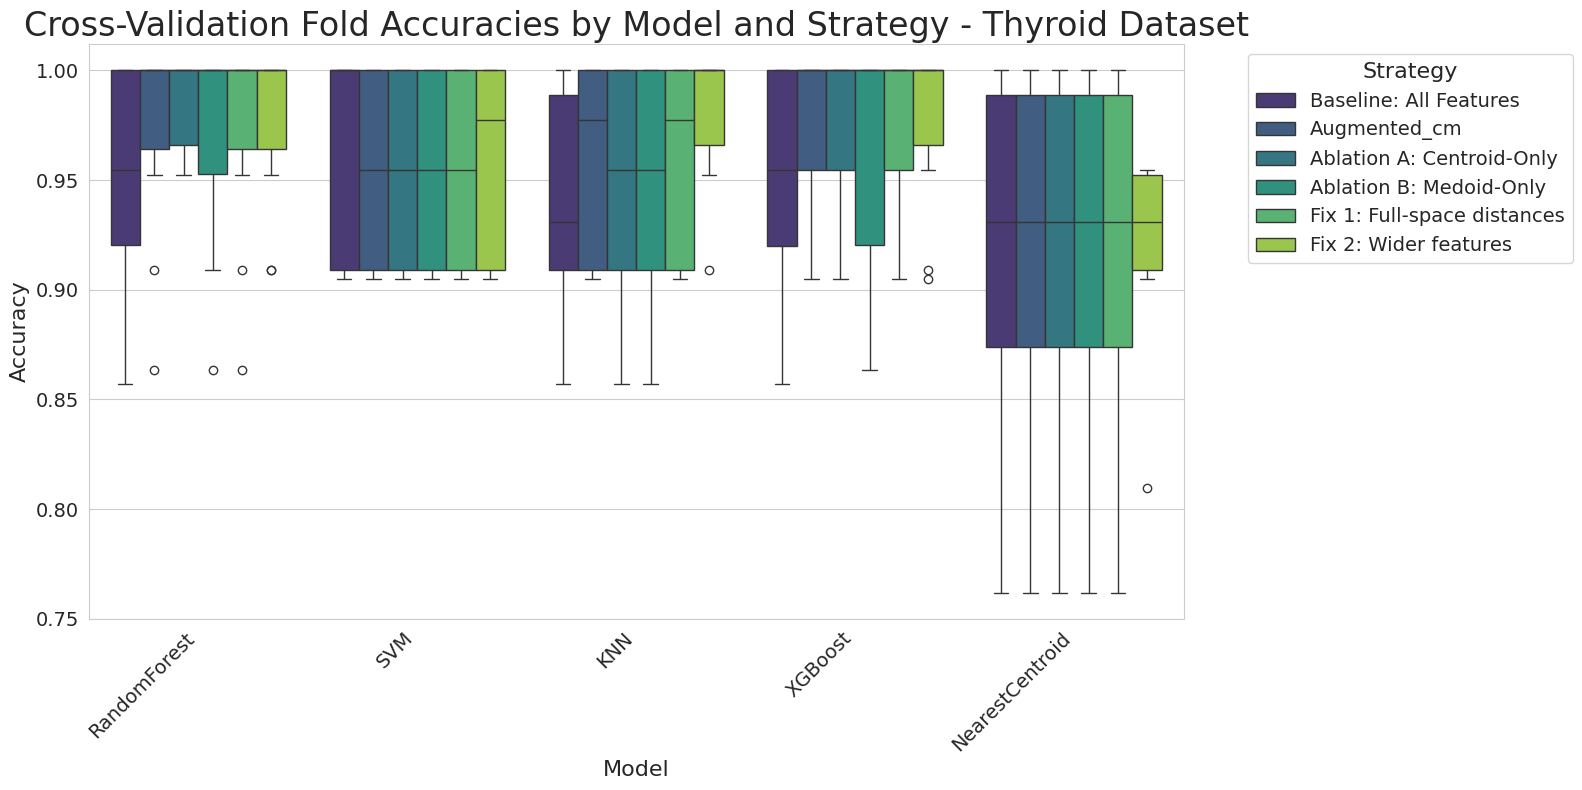

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for boxplot
boxplot_data = []
for result in all_results:
    if '_fold_accuracies' in result:
        model_name = result['Model']
        strategy_name = result['Strategy']
        for acc in result['_fold_accuracies']:
            boxplot_data.append({'Model': model_name, 'Strategy': strategy_name, 'Accuracy': acc})

boxplot_df = pd.DataFrame(boxplot_data)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Create the boxplot
sns.boxplot(data=boxplot_df, x='Model', y='Accuracy', hue='Strategy', palette='viridis')

# Customize plot titles and labels
plt.title('Cross-Validation Fold Accuracies by Model and Strategy - Thyroid Dataset', fontsize=24) # Increased title fontsize
plt.xlabel('Model', fontsize=16) # Increased x-label fontsize
plt.ylabel('Accuracy', fontsize=16) # Increased y-label fontsize
plt.xticks(rotation=45, ha='right', fontsize=14) # Increased x-tick fontsize
plt.yticks(fontsize=14) # Increased y-tick fontsize
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16) # Increased legend font sizes
plt.tight_layout()
plt.show()

Generating confusion matrix for: Model='RandomForest', Strategy='Baseline: All Features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

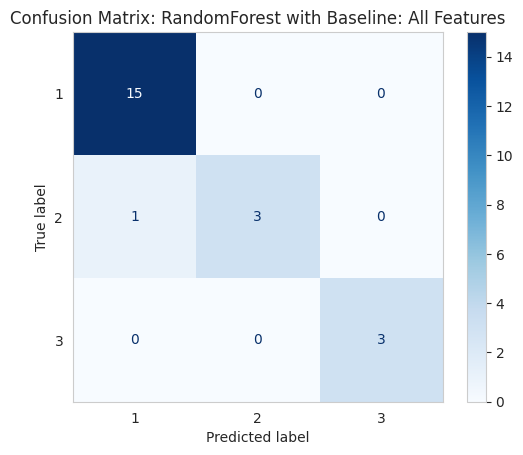

Generating confusion matrix for: Model='RandomForest', Strategy='Augmented_cm' (from one CV fold).


<Figure size 800x600 with 0 Axes>

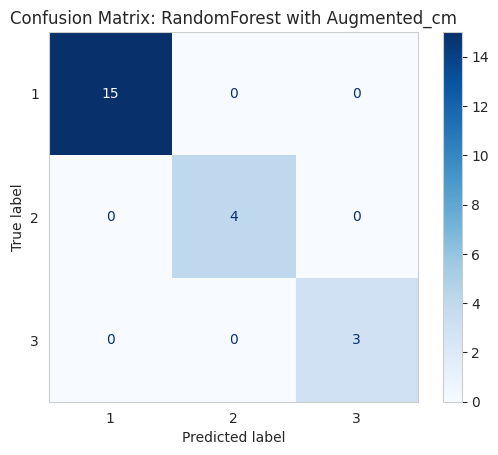

Generating confusion matrix for: Model='RandomForest', Strategy='Ablation A: Centroid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

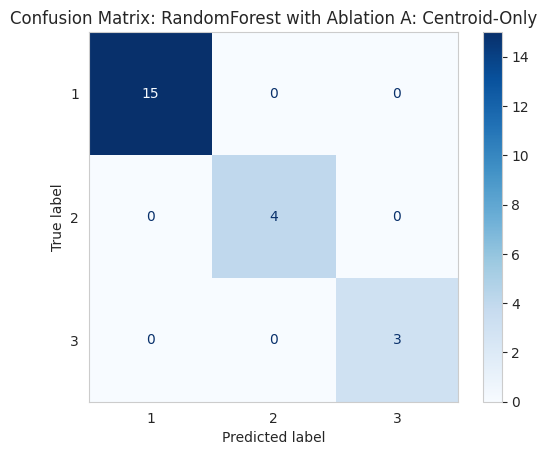

Generating confusion matrix for: Model='RandomForest', Strategy='Ablation B: Medoid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

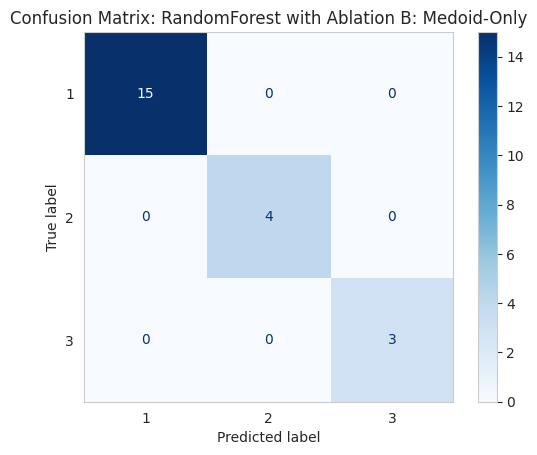

Generating confusion matrix for: Model='RandomForest', Strategy='Fix 1: Full-space distances' (from one CV fold).


<Figure size 800x600 with 0 Axes>

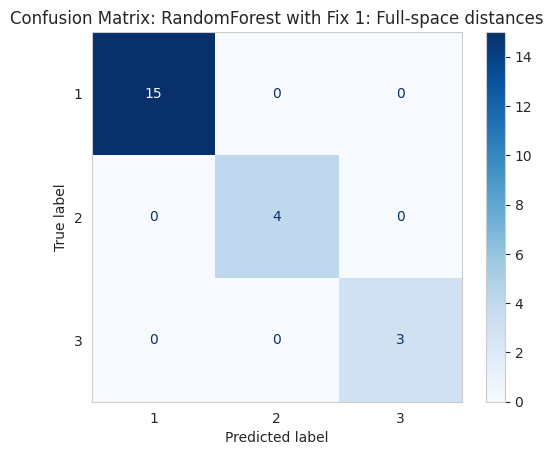

Generating confusion matrix for: Model='RandomForest', Strategy='Fix 2: Wider features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

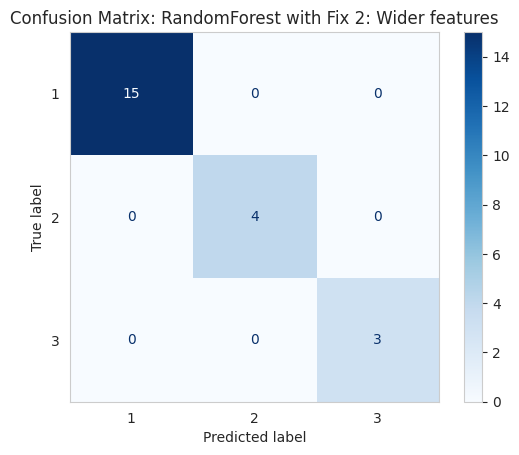

Generating confusion matrix for: Model='SVM', Strategy='Baseline: All Features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

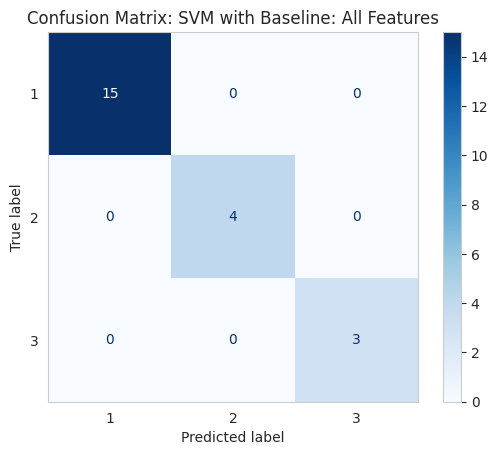

Generating confusion matrix for: Model='SVM', Strategy='Augmented_cm' (from one CV fold).


<Figure size 800x600 with 0 Axes>

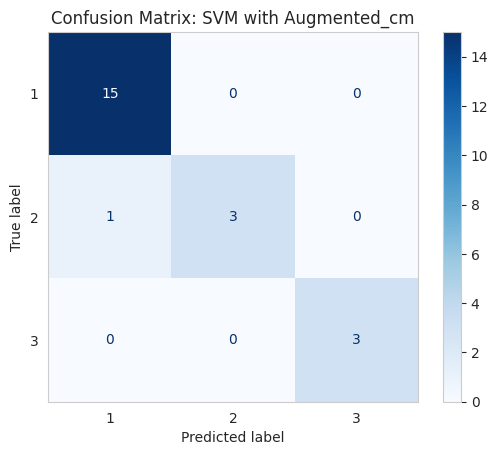

Generating confusion matrix for: Model='SVM', Strategy='Ablation A: Centroid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

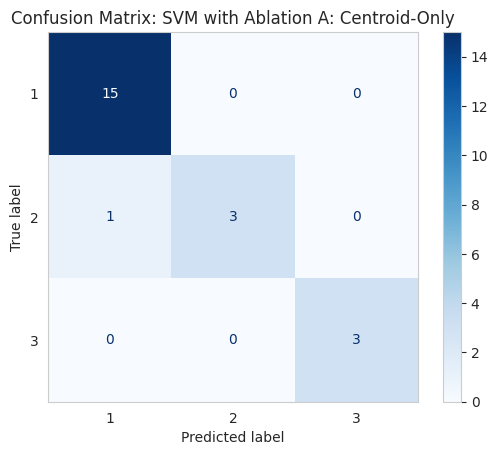

Generating confusion matrix for: Model='SVM', Strategy='Ablation B: Medoid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

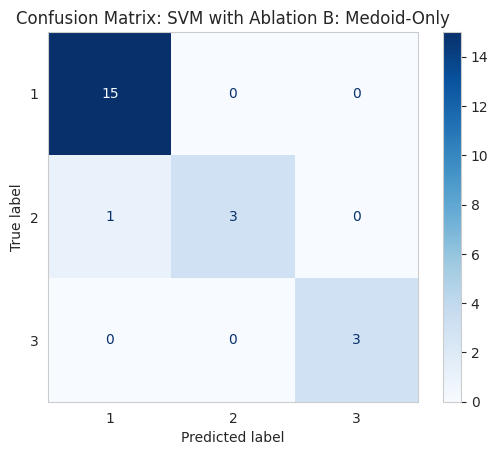

Generating confusion matrix for: Model='SVM', Strategy='Fix 1: Full-space distances' (from one CV fold).


<Figure size 800x600 with 0 Axes>

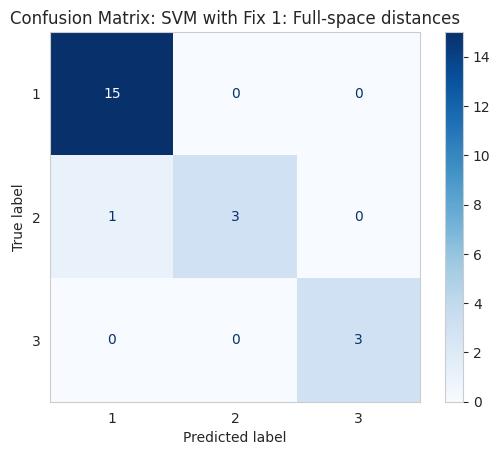

Generating confusion matrix for: Model='SVM', Strategy='Fix 2: Wider features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

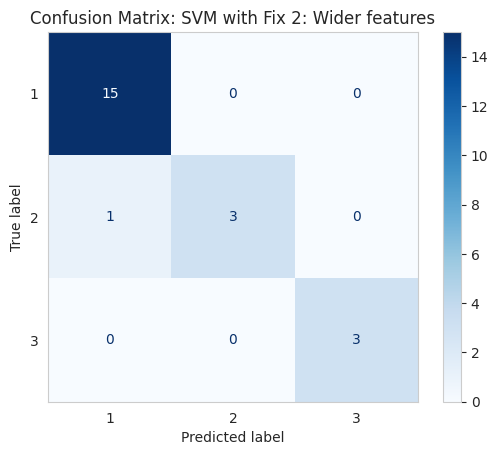

Generating confusion matrix for: Model='KNN', Strategy='Baseline: All Features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

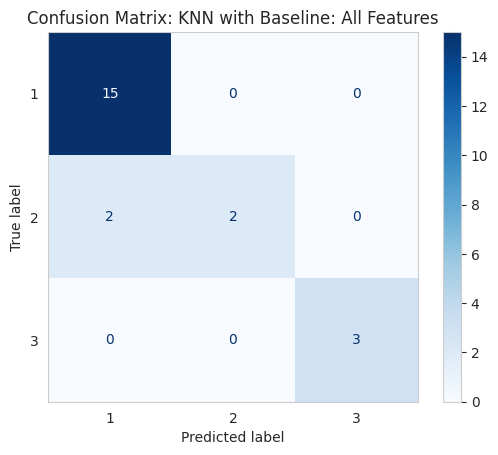

Generating confusion matrix for: Model='KNN', Strategy='Augmented_cm' (from one CV fold).


<Figure size 800x600 with 0 Axes>

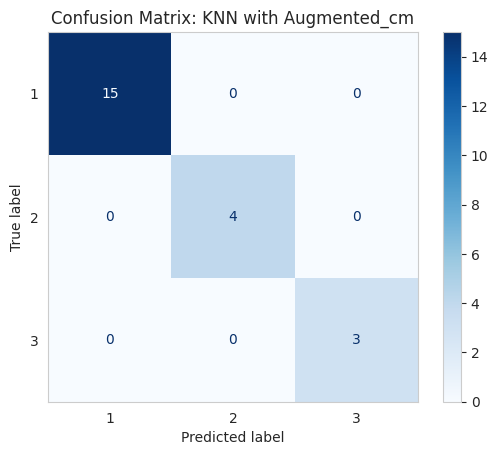

Generating confusion matrix for: Model='KNN', Strategy='Ablation A: Centroid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

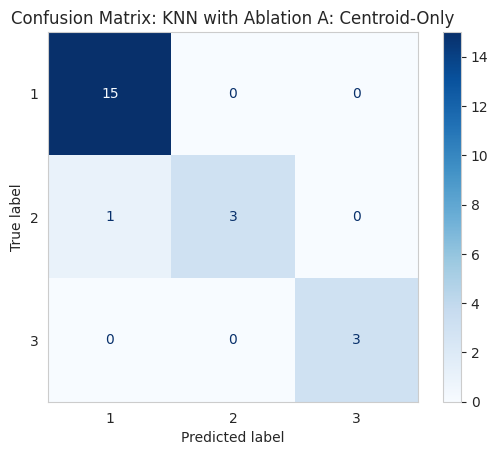

Generating confusion matrix for: Model='KNN', Strategy='Ablation B: Medoid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

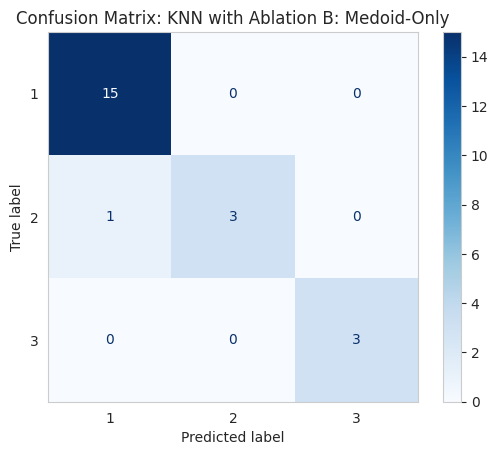

Generating confusion matrix for: Model='KNN', Strategy='Fix 1: Full-space distances' (from one CV fold).


<Figure size 800x600 with 0 Axes>

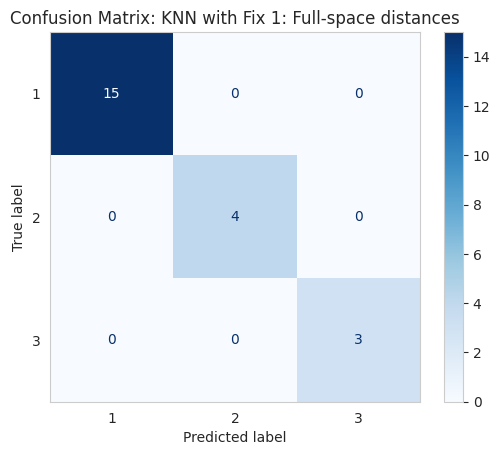

Generating confusion matrix for: Model='KNN', Strategy='Fix 2: Wider features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

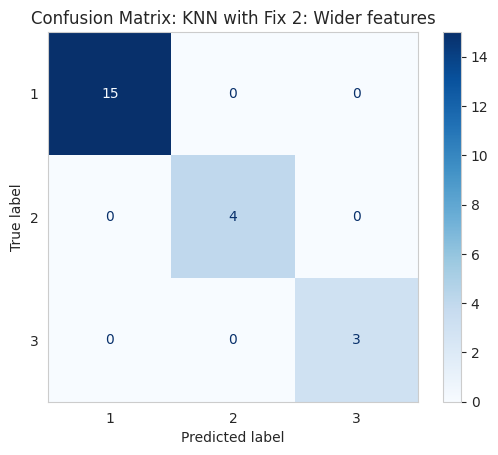

Generating confusion matrix for: Model='XGBoost', Strategy='Baseline: All Features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

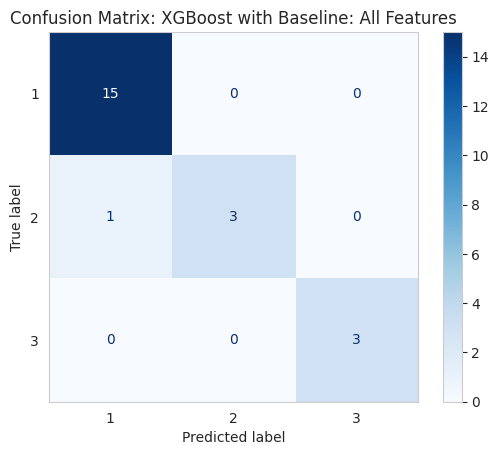

Generating confusion matrix for: Model='XGBoost', Strategy='Augmented_cm' (from one CV fold).


<Figure size 800x600 with 0 Axes>

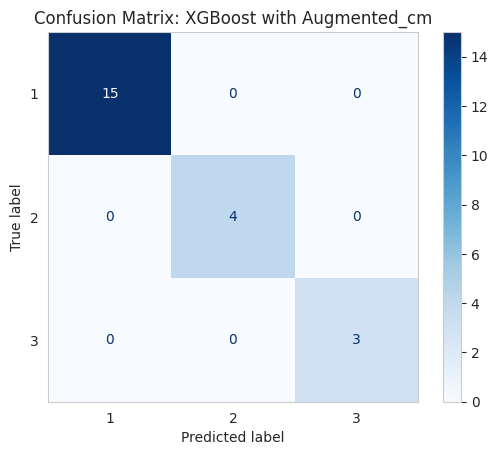

Generating confusion matrix for: Model='XGBoost', Strategy='Ablation A: Centroid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

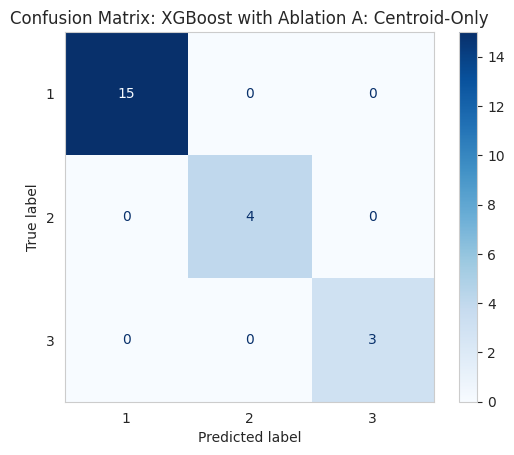

Generating confusion matrix for: Model='XGBoost', Strategy='Ablation B: Medoid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

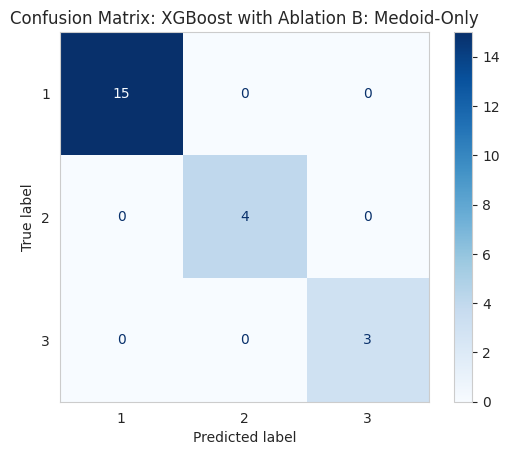

Generating confusion matrix for: Model='XGBoost', Strategy='Fix 1: Full-space distances' (from one CV fold).


<Figure size 800x600 with 0 Axes>

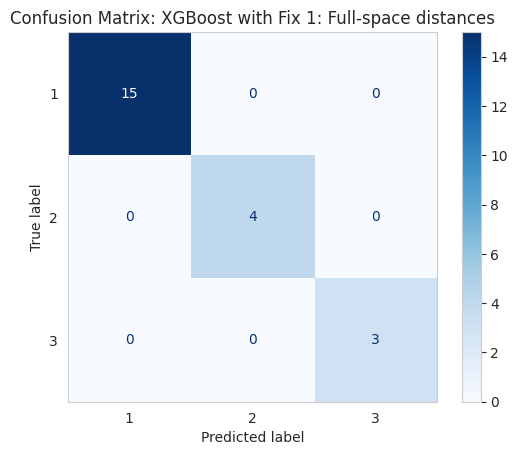

Generating confusion matrix for: Model='XGBoost', Strategy='Fix 2: Wider features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

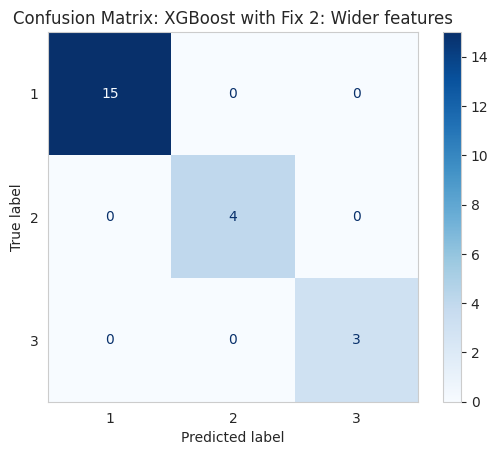

Generating confusion matrix for: Model='NearestCentroid', Strategy='Baseline: All Features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

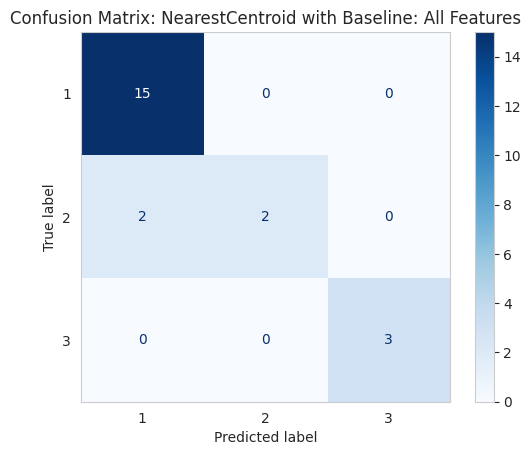

Generating confusion matrix for: Model='NearestCentroid', Strategy='Augmented_cm' (from one CV fold).


<Figure size 800x600 with 0 Axes>

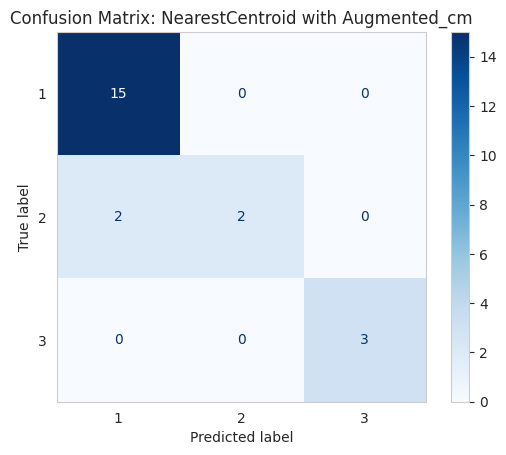

Generating confusion matrix for: Model='NearestCentroid', Strategy='Ablation A: Centroid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

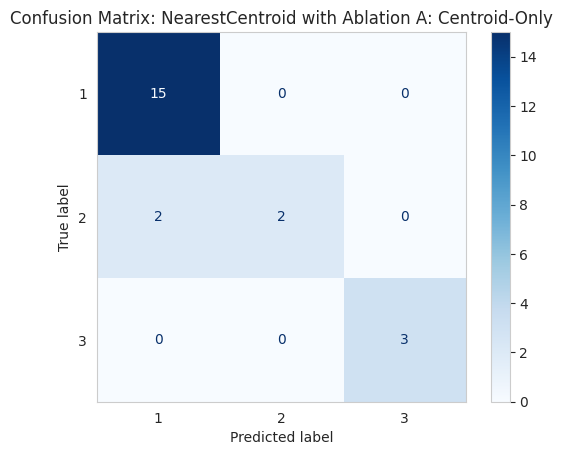

Generating confusion matrix for: Model='NearestCentroid', Strategy='Ablation B: Medoid-Only' (from one CV fold).


<Figure size 800x600 with 0 Axes>

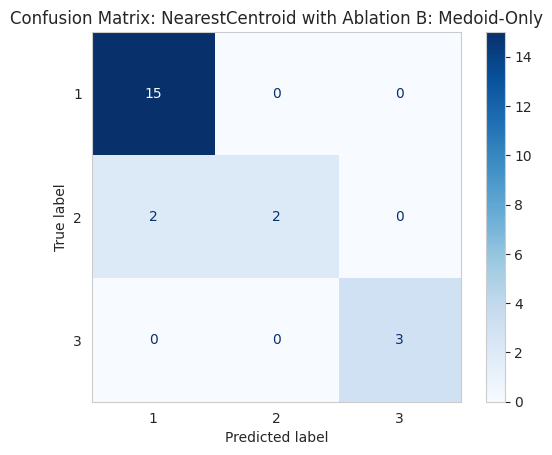

Generating confusion matrix for: Model='NearestCentroid', Strategy='Fix 1: Full-space distances' (from one CV fold).


<Figure size 800x600 with 0 Axes>

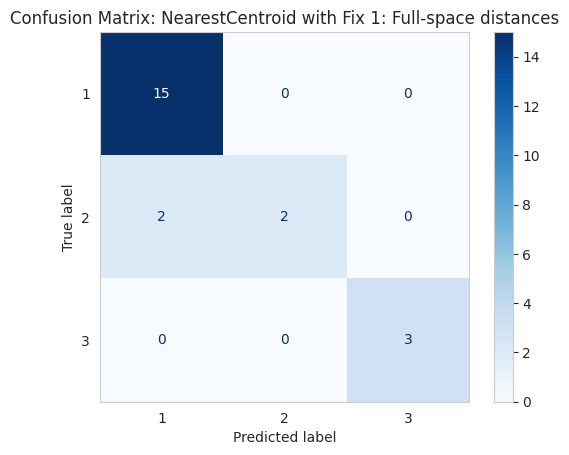

Generating confusion matrix for: Model='NearestCentroid', Strategy='Fix 2: Wider features' (from one CV fold).


<Figure size 800x600 with 0 Axes>

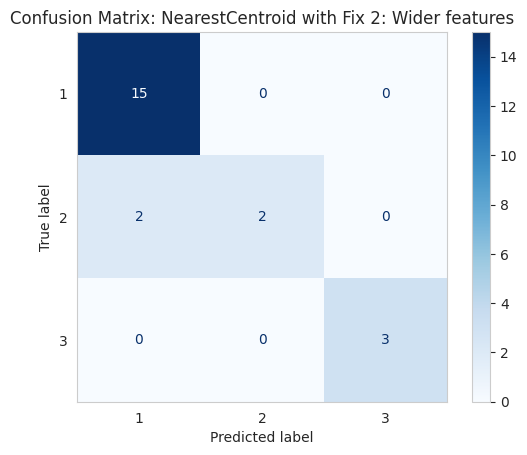

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- Configuration for confusion matrix generation ---
N_SPLITS_CM_DEMO = 10 # Using the same number of splits as the main CV for consistency
RANDOM_STATE_CM_DEMO = 42

# Strategies to generate confusion matrices for
strategies_to_plot = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',
]

# Initialize StratifiedKFold once for consistency across all plots
skf_cm_demo = StratifiedKFold(n_splits=N_SPLITS_CM_DEMO, shuffle=True, random_state=RANDOM_STATE_CM_DEMO)

# Get a single train-test split for demonstration purposes
# We'll just take the first split to generate a representative confusion matrix for all plots
train_idx, test_idx = next(skf_cm_demo.split(X, y))

X_tr_base, X_te_base = X.iloc[train_idx], X.iloc[test_idx]
y_tr_base, y_te_base = y.iloc[train_idx], y.iloc[test_idx]


for model_name, (model_class, model_params) in models_to_evaluate.items():
    for strategy_name in strategies_to_plot:
        print(f"Generating confusion matrix for: Model='{model_name}', Strategy='{strategy_name}' (from one CV fold).")

        # Reset X_tr, X_te, y_tr, y_te for each iteration based on the common fold
        X_tr, X_te = X_tr_base.copy(), X_te_base.copy()
        y_tr, y_te = y_tr_base.copy(), y_te_base.copy()

        # Placeholder for processed data
        X_tr_processed, X_te_processed = None, None
        y_pred = None

        # --- Strategy-specific data preparation ---
        if strategy_name == 'Baseline: All Features':
            all_cols = X.columns.tolist()
            scaler = StandardScaler()
            X_tr_processed = pd.DataFrame(scaler.fit_transform(X_tr[all_cols]),
                                            columns=all_cols, index=X_tr.index)
            X_te_processed = pd.DataFrame(scaler.transform(X_te[all_cols]),
                                            columns=all_cols, index=X_te.index)

        elif strategy_name in ['Augmented_cm', 'Ablation A: Centroid-Only', 'Ablation B: Medoid-Only']:
            fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=RANDOM_STATE_CM_DEMO)

            if model_class.__name__ == 'NearestCentroid':
                scaler = StandardScaler()
                X_tr_processed = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                                columns=fold_top_feats, index=X_tr.index)
                X_te_processed = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                                columns=fold_top_feats, index=X_te.index)
            else:
                scaler = StandardScaler()
                X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                            columns=fold_top_feats, index=X_tr.index)
                X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                            columns=fold_top_feats, index=X_te.index)

                train_sc = X_tr_sc.copy()
                train_sc['Class'] = y_tr
                grouped  = train_sc.groupby('Class')
                centroids = grouped[fold_top_feats].mean()
                medoids   = pd.DataFrame(
                    {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
                     for cls, g in grouped}).T

                def augment_features(X_sc_data, strategy):
                    X_aug = X_sc_data.copy()
                    if strategy in ['Augmented_cm', 'Ablation A: Centroid-Only']:
                        for cls in centroids.index:
                            X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                                X_sc_data[fold_top_feats].values - centroids.loc[cls].values, axis=1)
                    if strategy in ['Augmented_cm', 'Ablation B: Medoid-Only']:
                        for cls in medoids.index:
                            X_aug[f'dist_medoid_{cls}']   = np.linalg.norm(
                                X_sc_data[fold_top_feats].values - medoids.loc[cls].values,   axis=1)
                    return X_aug

                X_tr_processed = augment_features(X_tr_sc, strategy_name)
                X_te_processed = augment_features(X_te_sc, strategy_name)

        elif strategy_name in ['Fix 1: Full-space distances', 'Fix 2: Wider features']:
            all_cols = X.columns.tolist()

            if strategy_name == 'Fix 1: Full-space distances':
                current_strategy_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=RANDOM_STATE_CM_DEMO)
                # NCC in Fix 1 uses all features for scaling, not just filtered ones for its base input
                base_input_feats = all_cols
            else: # 'Fix 2: Wider features'
                current_strategy_feats = get_wider_features_in_fold(X_tr, y_tr, random_state=RANDOM_STATE_CM_DEMO)
                # NCC in Fix 2 uses wider features for scaling
                base_input_feats = current_strategy_feats

            if model_class.__name__ == 'NearestCentroid':
                scaler = StandardScaler()
                X_tr_processed = pd.DataFrame(scaler.fit_transform(X_tr[base_input_feats]),
                                                columns=base_input_feats, index=X_tr.index)
                X_te_processed = pd.DataFrame(scaler.transform(X_te[base_input_feats]),
                                                columns=base_input_feats, index=X_te.index)
            else:
                full_scaler  = StandardScaler()
                X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
                X_te_full_sc = full_scaler.transform(X_te[all_cols])

                train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
                train_full_df['Class'] = y_tr
                grouped_full   = train_full_df.groupby('Class')
                centroids_full = grouped_full[all_cols].mean()
                medoids_full   = pd.DataFrame(
                    {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
                     for cls, g in grouped_full}).T

                filt_scaler  = StandardScaler()
                X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[current_strategy_feats]),
                                             columns=current_strategy_feats, index=X_tr.index)
                X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[current_strategy_feats]),
                                             columns=current_strategy_feats, index=X_te.index)

                def augment_full_space(X_filt_sc, X_full_sc_arr):
                    X_aug = X_filt_sc.copy()
                    for cls in centroids_full.index:
                        X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                            X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                        X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                            X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
                    return X_aug

                X_tr_processed = augment_full_space(X_tr_filt_sc, X_tr_full_sc)
                X_te_processed = augment_full_space(X_te_filt_sc, X_te_full_sc)
        else:
            print(f"ERROR: Unknown strategy '{strategy_name}'. Skipping confusion matrix.")
            continue

        # --- Train and predict with the chosen model ---
        # Only proceed if X_tr_processed and X_te_processed were successfully created
        if X_tr_processed is not None and X_te_processed is not None:
            model = model_class(**model_params)
            model.fit(X_tr_processed, y_tr)
            y_pred = model.predict(X_te_processed)
        else:
            print(f"Skipping {model_name} with {strategy_name} due to data processing error.")
            continue

        # --- Plot Confusion Matrix ---
        cm_labels = sorted(le.transform(class_names))
        cm = confusion_matrix(y_te, y_pred, labels=cm_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

        plt.figure(figsize=(8, 6))
        disp.plot(cmap=plt.cm.Blues, values_format='d')
        plt.title(f'Confusion Matrix: {model_name} with {strategy_name}')
        plt.grid(False)
        plt.show()

